# L17: Image processing

### Set up imports

In [21]:
# !pip install matplotlib
# !pip install scikit-learn
# !pip install scikit-image
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 26.2 MB/s  0:00:00m0:00:010:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### Load an example image

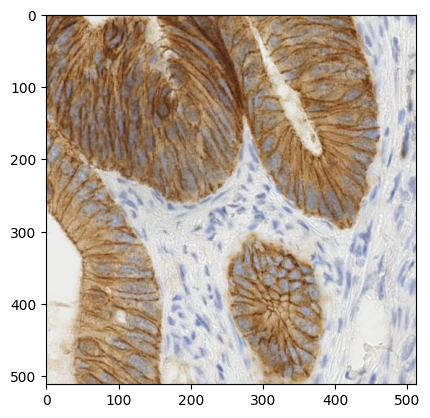

In [5]:
image = data.immunohistochemistry()

# look at the image
plt.imshow(image)

### Analyze the image

In [6]:
# look at the shape
image.shape

(512, 512, 3)

In [7]:
# look at top left pixel
image[0, 0, :]

array([156, 118,  81], dtype=uint8)

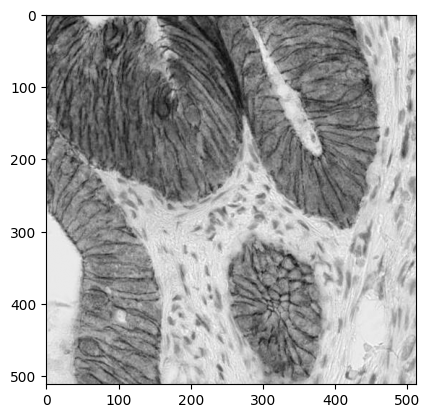

In [9]:
# convert image to grayscale
image_gray = rgb2gray(image)

plt.imshow(image_gray, cmap='gray')

In [10]:
# look at top left pixel, again
image_gray[0, 0]

np.float64(0.4839501960784314)

Text(0.5, 1.0, 'First row gray data')

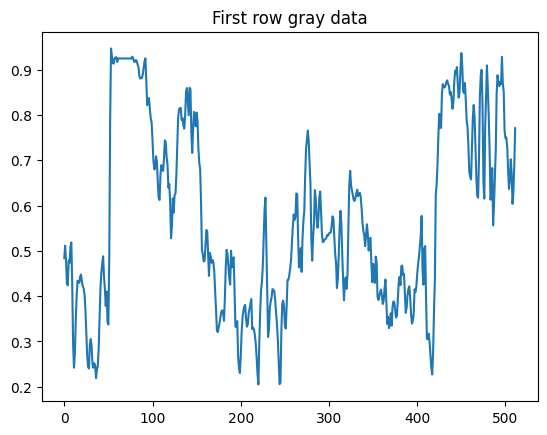

In [14]:
# plot values of the top row as a line graph
first_row_data = image_gray[0, :]

plt.plot(first_row_data)
plt.title('First row gray data')

### Split into red, green, and blue images

In [15]:
red_image = image[:, :, 0]
blue_image = image[:, :, 1]
green_image = image[:, :, 2]

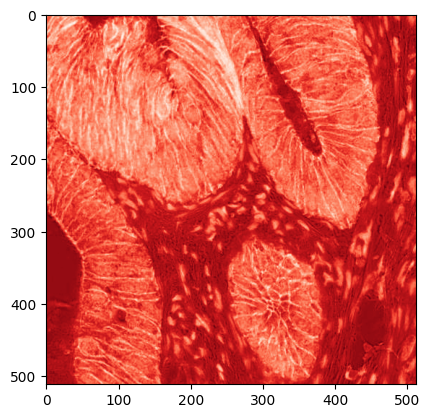

In [17]:
plt.imshow(red_image, cmap='Reds')

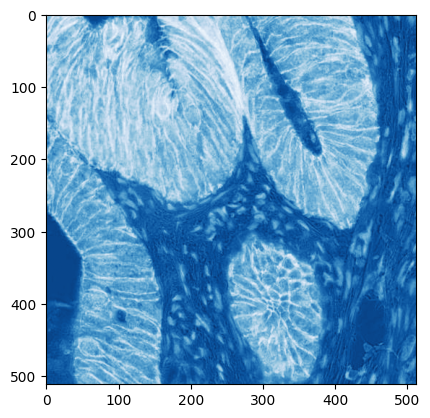

In [18]:
plt.imshow(blue_image, cmap='Blues')

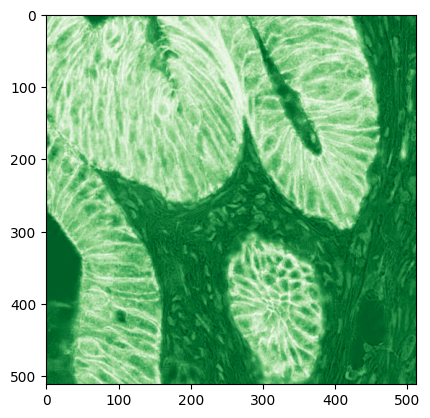

In [ ]:
plt.imshow(green_image, cmap='Greens')

### Apply Random forest to mnist data

### Load the data

In [23]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

### Split data

In [28]:
X, y = mnist['data'], mnist['target']

# only use the first 5,000 images
X = X[:5000, :]
y = y[:5000]

X.shape
y.shape

(5000,)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Train the model

In [30]:
# define the model
clf = RandomForestClassifier(random_state=42)

# train it
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Make test set predictions

In [32]:
y_pred = clf.predict(X_test)

In [33]:
acc = accuracy_score(y_test, y_pred)

acc

0.9336

# Activity: Understand the model's errors

Goal: Find the first 10 inaccurate predictions in the test set, and print the true value and the predicted value

Steps: 
1. define a counter variable to start at zero
2. write a loop to look at each pair of true and predicted y values
3. check if the true value matches or is different from the predicted value and the counter variable is less than 10
4. if they are different, then print out the true and predicted value. Also increase the counter variable by one

In [37]:
# define counter
num_errors = 0

# define loop
for true_value, pred_value in zip(y_test, y_pred):

    # check if there is an error
    if true_value != pred_value and num_errors < 10:
        print(f'true value: {true_value}, predicted value: {pred_value}')

        # increase the counter
        num_errors = num_errors + 1


true value: 3, predicted value: 5
true value: 0, predicted value: 8
true value: 3, predicted value: 5
true value: 1, predicted value: 5
true value: 7, predicted value: 3
true value: 3, predicted value: 7
true value: 5, predicted value: 7
true value: 7, predicted value: 2
true value: 4, predicted value: 6
true value: 1, predicted value: 8
